# Figure 3 — TG/DTG Profiles

Notebook version of `03_build_figure3_TG_DTG_profiles.py`.

This notebook preserves the original scientific workflow:

- Figure 3 uses the same canonical cleaned mass profiles as the kinetic preprocessing pipeline.
- DTG is displayed only after the verified 90% stable-ramp onset.
- Supplementary Figure S2 uses instrument-recorded time-domain mass without terminal-baseline correction.
- **All figure typography is set to Times New Roman.**


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager

# In notebooks, __file__ is unavailable. Use the notebook working directory.
CODE_DIR = Path.cwd()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from alc_core import (
    BETAS, FIG_MAIN_DIR, FIG_SUPP_DIR, RESULTS_DIR,
    canonical_clean_curve, load_raw_curve, stable_ramp_onset, save_figure,
)

FIG_MAIN_DIR.mkdir(parents=True, exist_ok=True)
FIG_SUPP_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## Times New Roman publication style

In [2]:
# Strict Times New Roman check
font_manager._load_fontmanager(try_read_cache=False)

if "Times New Roman" not in {f.name for f in font_manager.fontManager.ttflist}:
    raise RuntimeError(
        "Times New Roman is not installed or not available to Matplotlib."
    )

COLORS = {5: "#1f77b4", 10: "#d95f02", 20: "#2ca02c"}

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 9.2,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9.2,
    "ytick.labelsize": 9.2,
    "legend.fontsize": 8.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


## Build canonical TG curves and stable-ramp onset tables

In [3]:
tg_curves = {}
onset_rows = []
disclosure_rows = []

for atm in ("N2", "Air"):
    for beta in BETAS:
        clean, offset_1000 = canonical_clean_curve(atm, beta)
        raw = load_raw_curve(atm, beta)
        onset = stable_ramp_onset(
            raw, beta,
            fraction=0.90,
            min_duration_s=60.0,
        )

        tg_curves[(atm, beta)] = clean

        onset_rows.append({
            "atmosphere": atm,
            "beta_C_per_min": beta,
            "onset_time_s": onset["onset_time_s"],
            "onset_temperature_K": onset["onset_temperature_K"],
        })

        disclosure_rows.append({
            "atmosphere": atm,
            "beta_C_per_min": beta,
            "canonical_grid_terminal_offset_at_1000K_pct": offset_1000,
            "canonical_cleaned_final_mass_pct": float(clean.mass_clean_pct.iloc[-1]),
            "baseline_mode":
                "constant additive offset at 1000 K" if atm == "Air" else "none",
        })

onset_df = pd.DataFrame(onset_rows)
disclosure_df = pd.DataFrame(disclosure_rows)

onset_df.to_csv(
    RESULTS_DIR / "Figure3_stable_ramp_onsets.csv",
    index=False,
)
disclosure_df.to_csv(
    RESULTS_DIR / "Figure3_terminal_baseline_disclosure.csv",
    index=False,
)

display(disclosure_df)


,atmosphere,beta_C_per_min,canonical_grid_terminal_offset_at_1000K_pct,canonical_cleaned_final_mass_pct,baseline_mode
0,N2,5,0.000000,2.628718,none
1,N2,10,0.000000,2.666481,none
2,N2,20,0.000000,3.102807,none
3,Air,5,-0.045640,-0.000275,constant additive offset at 1000 K
4,Air,10,-0.316204,-0.000072,constant additive offset at 1000 K
5,Air,20,0.319437,-0.000302,constant additive offset at 1000 K


## Generate main Figure 3 — TG/DTG profiles

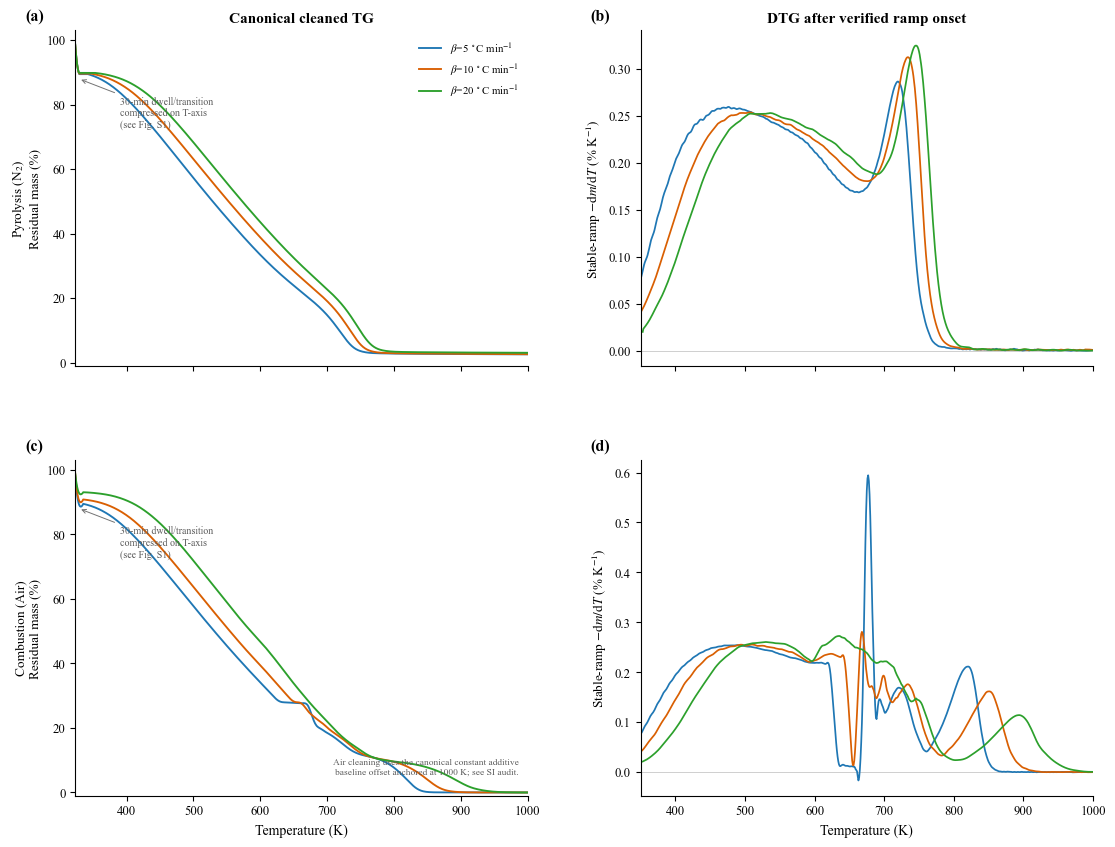

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.6), sharex="col")

for row, atm in enumerate(("N2", "Air")):
    ax_tg, ax_dtg = axes[row, 0], axes[row, 1]
    title = "Pyrolysis (N$_2$)" if atm == "N2" else "Combustion (Air)"

    for beta in BETAS:
        curve = tg_curves[(atm, beta)]

        ax_tg.plot(
            curve.temperature_K,
            curve.mass_clean_pct,
            color=COLORS[beta],
            lw=1.35,
            label=rf"$\beta$={beta} $^\circ$C min$^{{-1}}$" if row == 0 else None,
        )

        onset_T = float(
            onset_df[
                (onset_df.atmosphere == atm)
                & (onset_df.beta_C_per_min == beta)
            ].onset_temperature_K.iloc[0]
        )

        ramp = curve[
            curve.temperature_K >= max(350.0, onset_T + 20.0)
        ]

        ax_dtg.plot(
            ramp.temperature_K,
            ramp.dtg_pct_per_K,
            color=COLORS[beta],
            lw=1.25,
        )

    ax_tg.set_xlim(323, 1000)
    ax_tg.set_ylim(-1, 103)
    ax_tg.set_ylabel(f"{title}\nResidual mass (%)", fontsize=9.6)

    ax_dtg.axhline(0, color="0.78", lw=0.6, zorder=0)
    ax_dtg.set_xlim(350, 1000)
    ax_dtg.set_ylabel(
        r"Stable-ramp $-\mathrm{d}m/\mathrm{d}T$ (% K$^{-1}$)",
        fontsize=9.5,
    )

    if row == 0:
        ax_tg.set_title("Canonical cleaned TG", fontweight="bold")
        ax_dtg.set_title("DTG after verified ramp onset", fontweight="bold")
        ax_tg.legend(frameon=False, fontsize=7.8, loc="upper right")
    else:
        ax_tg.set_xlabel("Temperature (K)")
        ax_dtg.set_xlabel("Temperature (K)")

    ax_tg.annotate(
        "30-min dwell/transition\ncompressed on T-axis\n(see Fig. S1)",
        xy=(328, 88),
        xytext=(390, 73),
        fontsize=7.2,
        color="0.35",
        arrowprops=dict(arrowstyle="->", color="0.45", lw=0.7),
    )

    for ax in (ax_tg, ax_dtg):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

axes[1, 0].text(
    0.98, 0.06,
    "Air cleaning uses the canonical constant additive\n"
    "baseline offset anchored at 1000 K; see SI audit.",
    transform=axes[1, 0].transAxes,
    ha="right", va="bottom",
    fontsize=6.8, color="0.35",
)

for ax, label in zip(axes.flat, ["(a)", "(b)", "(c)", "(d)"]):
    ax.text(
        -0.11, 1.03, label,
        transform=ax.transAxes,
        fontsize=11.5,
        fontweight="bold",
    )

fig.subplots_adjust(
    left=0.10, right=0.985,
    top=0.97, bottom=0.08,
    hspace=0.28, wspace=0.25,
)

plt.show()


## Save main Figure 3

In [6]:
save_figure(
    fig,
    FIG_MAIN_DIR / "Figure3_TG_DTG_profiles.png",
    FIG_MAIN_DIR / "Figure3_TG_DTG_profiles.pdf",
    dpi=400,
)

print("Wrote Figure3_TG_DTG_profiles.png / .pdf")


Wrote Figure3_TG_DTG_profiles.png / .pdf


## Supplementary Figure S2 — raw time-domain mass comparison

This figure deliberately uses the instrument-recorded raw mass values without terminal-baseline correction.


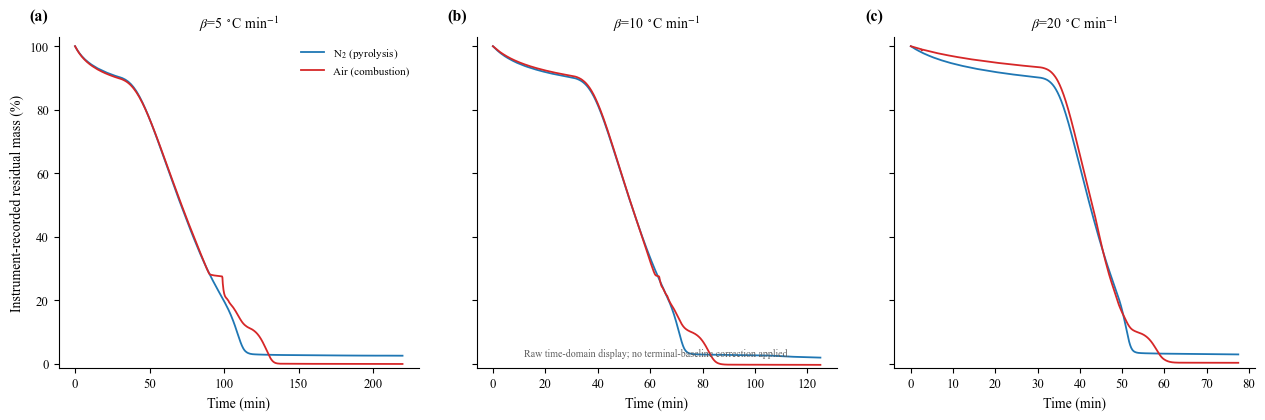

In [7]:
fig2, axes2 = plt.subplots(1, 3, figsize=(13.0, 4.2), sharey=True)

for ax, beta in zip(axes2, BETAS):
    n2 = load_raw_curve("N2", beta)
    air = load_raw_curve("Air", beta)

    ax.plot(
        n2.time_s / 60.0, n2.mass_pct,
        color="#1f77b4", lw=1.3,
        label="N$_2$ (pyrolysis)",
    )
    ax.plot(
        air.time_s / 60.0, air.mass_pct,
        color="#d62728", lw=1.3,
        label="Air (combustion)",
    )

    ax.set_title(
        rf"$\beta$={beta} $^\circ$C min$^{{-1}}$",
        fontsize=10,
    )
    ax.set_xlabel("Time (min)")
    ax.set_ylim(-1.5, 103)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes2[0].set_ylabel("Instrument-recorded residual mass (%)")
axes2[0].legend(loc="upper right", frameon=False, fontsize=8)

axes2[1].text(
    0.5, 0.03,
    "Raw time-domain display; no terminal-baseline correction applied.",
    transform=axes2[1].transAxes,
    ha="center", va="bottom",
    fontsize=7.2, color="0.35",
)

for ax, label in zip(axes2, ["(a)", "(b)", "(c)"]):
    ax.text(
        -0.08, 1.05, label,
        transform=ax.transAxes,
        fontsize=11.5,
        fontweight="bold",
    )

fig2.subplots_adjust(
    left=0.07, right=0.99,
    top=0.93, bottom=0.14,
    wspace=0.16,
)

plt.show()


## Save Supplementary Figure S2

In [8]:
save_figure(
    fig2,
    FIG_SUPP_DIR / "FigureS2_time_domain_mass_comparison.png",
    FIG_SUPP_DIR / "FigureS2_time_domain_mass_comparison.pdf",
    dpi=400,
)

print("Wrote FigureS2_time_domain_mass_comparison.png / .pdf")


Wrote FigureS2_time_domain_mass_comparison.png / .pdf
